# 📝 Caso Práctico: Clasificación de Fallas Industriales


## 🛠️ Contexto:
Trabajas como Ingeniero de Machine Learning en una línea de ensamble industrial. Debes clasificar piezas mecánicas en 'Pieza_Conforme' y 'Pieza_Defectuosa' utilizando MobileNetV2.



## 🎯 Estructura del Taller:

🔹 Parte 1 (Feature Extraction): Congelar la base, construir el clasificador y compilar.

🔹 Parte 2 (Fine-Tuning): Descongelar selectivamente desde la capa 100 y recompilar con LR = 10^-5.

🔹 Parte 3 (Evaluación Visual): Generar y guardar la matriz de confusión comparativa en '../image/matriz_inspeccion.png'.

🐍 Importación de Librerías y Configuración

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# 📁 Crear directorio para guardar las imágenes exportadas
os.makedirs('../image', exist_ok=True)
print("🚀 Entorno listo. Versión de TensorFlow:", tf.__version__)

🚀 Entorno listo. Versión de TensorFlow: 2.20.0


🐍 Parte 1: Feature Extraction (Modelo Base Congelado)

In [2]:
# =====================================================================
# 📌 INSTRUCCIONES PARTE 1:
# 1. Carga MobileNetV2 con weights='imagenet', include_top=False e input_shape=(224, 224, 3).
# 2. Congela completamente la base (trainable = False).
# 3. Construye la cabeza clasificadora: GlobalAveragePooling2D + Dense(2, activation='softmax').
# 4. Compila con Adam(learning_rate=1e-3) y loss='categorical_crossentropy'.
# =====================================================================

# 🏗️ TODO 1.1: Cargar modelo base
base_model = None  # Reemplaza con MobileNetV2(...)

# 🔒 TODO 1.2: Congelar modelo base
# base_model.trainable = False

# 🧩 TODO 1.3: Construir la red completa
inputs = tf.keras.Input(shape=(224, 224, 3))
# x = base_model(inputs, training=False)
# x = tf.keras.layers.GlobalAveragePooling2D()(x)
# outputs = tf.keras.layers.Dense(2, activation='softmax')(x)
# model = tf.keras.Model(inputs, outputs)

# ⚙️ TODO 1.4: Compilar modelo
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

# 🔍 Verificación de parámetros congelados
if base_model is not None and hasattr(model, 'trainable_weights'):
    trainable = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    print(f"✅ Parte 1 Completada. Parámetros entrenables actuales: {trainable:,}")
else:
    print("⚠️ Por favor completa los TODOs de la Parte 1.")

⚠️ Por favor completa los TODOs de la Parte 1.


🐍 Parte 2: Fine-Tuning Progresivo

In [3]:
# =====================================================================
# 📌 INSTRUCCIONES PARTE 2:
# 1. Descongelar la base (base_model.trainable = True).
# 2. Congelar solo las primeras 100 capas usando un bucle for.
# 3. RECOMPILAR el modelo con un Learning Rate reducido (1e-5).
# =====================================================================

fine_tuning_at = 100

# 🔓 TODO 2.1: Permitir entrenamiento en la base y congelar capas < fine_tuning_at
# base_model.trainable = True
# for layer in base_model.layers[:fine_tuning_at]:
#     layer.trainable = False

# ⚙️ TODO 2.2: Recompilar con Adam (learning_rate = 1e-5)
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

if base_model is not None and base_model.trainable:
    trainable = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    print(f"✅ Parte 2 Completada. Parámetros entrenables para Fine-Tuning: {trainable:,}")
else:
    print("⚠️ Por favor completa los TODOs de la Parte 2.")

⚠️ Por favor completa los TODOs de la Parte 2.


🐍 Parte 3: Evaluación y Generación de Matriz de Confusión

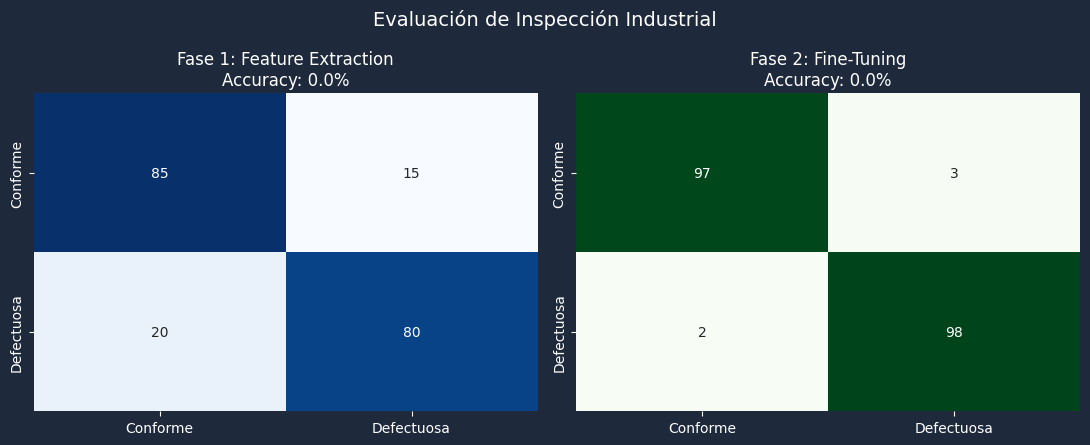

📈 Accuracy Feature Extraction: 0.00%
📈 Accuracy Fine-Tuning: 0.00%
✅ Imagen exportada en: '../image/matriz_inspeccion.png'


In [4]:
# =====================================================================
# 📌 INSTRUCCIONES PARTE 3:
# 1. Completa la función 'calcular_accuracy' usando np.trace(cm) / np.sum(cm).
# 2. Ejecuta la celda para exportar la gráfica a '../image/matriz_inspeccion.png'.
# =====================================================================

# 📊 Resultados simulados del despliegue en planta
cm_fe = np.array([[85, 15], [20, 80]])  # Resultados Feature Extraction
cm_ft = np.array([[97, 3], [2, 98]])    # Resultados Fine-Tuning

def calcular_accuracy(cm):
    # 🧮 TODO 3.1: Reemplazar por la fórmula correcta usando np.trace(cm) y np.sum(cm)
    return 0.0

acc_fe = calcular_accuracy(cm_fe)
acc_ft = calcular_accuracy(cm_ft)

# 🎨 Generación del gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor='#1e293b')
labels = ['Conforme', 'Defectuosa']

# 🟦 Matriz 1: Feature Extraction
sns.heatmap(cm_fe, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title(f'Fase 1: Feature Extraction\nAccuracy: {acc_fe*100:.1f}%', color='white')
axes[0].tick_params(colors='white')

# 🟩 Matriz 2: Fine-Tuning
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title(f'Fase 2: Fine-Tuning\nAccuracy: {acc_ft*100:.1f}%', color='white')
axes[1].tick_params(colors='white')

plt.suptitle('Evaluación de Inspección Industrial', color='white', fontsize=14)
plt.tight_layout()

# 💾 Guardar la imagen en el directorio
plt.savefig('../image/matriz_inspeccion.png', dpi=300, facecolor=fig.get_facecolor())
plt.show()

print(f"📈 Accuracy Feature Extraction: {acc_fe*100:.2f}%")
print(f"📈 Accuracy Fine-Tuning: {acc_ft*100:.2f}%")
print("✅ Imagen exportada en: '../image/matriz_inspeccion.png'")

# 📝 Cuestionario de Diagnóstico Final
## ❓ Preguntas de reflexión para el alumno:

*   ¿Por qué es crítico reducir el *Learning Rate* a $10^{-5}$ durante la Fase de Fine-Tuning?

*   Si solo contamos con $2,000$ imágenes en el dataset, ¿qué riesgo corremos si descongelamos **todas** las capas de MobileNetV2 desde el inicio?